In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=pd.read_csv(r"C:\Users\merve\Desktop\Calismalar\Credit-Risk-Dataset\credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [38]:
#person_home_ownership : ev sahipliği durumu rent:kiracı , own:ev sahibi , mortgage:ipotekli ev sahibi , other:diğer
#person_emp_length: yıl cinsinden çalışma süresi
#loan_intent: kredi nedeni VENTURE:girişimcilik , DEBTCONSOLIDATION:borç kapatma
#loan_grade : A en düşük riskli- en gvenli         loan_amnt: kredi tutarı
#loan_int_rate : faiz oranı
#loan_status : 1 geri ödendi , 0 borç ödenmedi (y)
#loan_percent_income : kredi/gelir ( loan_amnt/person_income)
#cb_person_default_on_file:kara liste kaydı
#cb_person_cred_hist_length : müşterinin ilk işleminden bu yana geçen süre(yıl) , banka müşteriyi tanır

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [40]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [41]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


In [42]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [43]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [44]:
find_outliers_iqr(df)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
outlier_count,1494.000000,1484.000000,853.00000,1689.000000,6.000000,7108.000000,651.000000,1142.00000
outlier_percentage,4.585495,4.554802,2.61809,5.184003,0.018416,21.816396,1.998097,3.50511
lower_bound,12.500000,-22550.000000,-5.50000,-5800.000000,-0.455000,0.000000,-0.120000,-4.50000
upper_bound,40.500000,140250.000000,14.50000,23000.000000,21.825000,0.000000,0.440000,15.50000


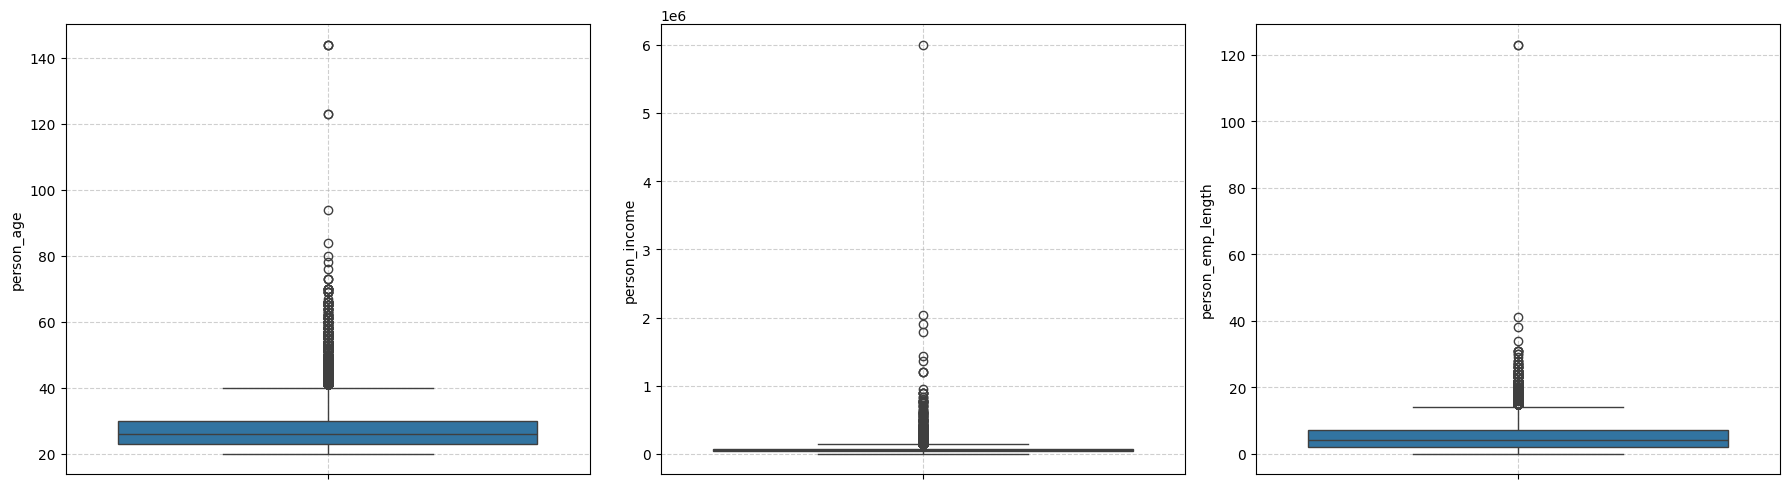

In [45]:
cols = ['person_age','person_income','person_emp_length']
fig , axes =plt.subplots(1,3,figsize=(18,5))

for i , col in enumerate(cols):
    sns.boxplot(y=df[col] , ax= axes[i] )
    axes[i].set_ylabel(col)
    axes[i].grid(True , linestyle = '--' ,alpha=0.6 )
    
plt.tight_layout()
plt.show()

In [46]:
df[df['person_emp_length']>60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [47]:
df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [48]:
df[df['person_income']>2500000]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.0,N,25


In [49]:
clean = (
    (df['person_age'] <= 100)
    & (
        (df['person_emp_length'] < 60) | (df['person_emp_length'].isnull())
    )  
    & (
        (df['person_emp_length'] < df['person_age'])
        | (df['person_emp_length'].isnull())
    )
    &
    (df['person_income'] <= 2500000)
)

df = df[clean].reset_index(drop=True)

In [50]:
df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [51]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [52]:
from sklearn.impute import SimpleImputer
emp_imp = SimpleImputer(strategy='median')
df['person_emp_length']=emp_imp.fit_transform(df[['person_emp_length']])

In [53]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32569,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32570,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32571,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32572,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [54]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median'))

In [55]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [56]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N':0 , 'Y':1})

In [57]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [58]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

#df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N':0 , 'Y':1})  bu işlemi x ve y olarak ayırmadan önce yapmalıyız

one_hot_col= ['person_home_ownership' , 'loan_intent' ]
ord_col = ['loan_grade']
num_col = [
    'person_age', 'person_income', 'person_emp_length', 
    'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
    'cb_person_cred_hist_length']

prep=ColumnTransformer(
    transformers=[
        ('onehotenc',OneHotEncoder(drop='first',handle_unknown='ignore') , one_hot_col),
        ('ordenc' , OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]), ord_col),
        ('scaler' , StandardScaler() , num_col),
    ], remainder='passthrough'
)

In [60]:
X_train_prep= prep.fit_transform(X_train)
X_test_prep = prep.transform(X_test)

In [61]:
#pipeline oluşturalım
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(random_state=42)

pipeline = Pipeline(steps=[
    ( 'preprocessor' , prep ),
    ('logistic' , log)
]
)

pipeline.fit(X_train,y_train)
y_pred_log = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_log,y_test))
print('classification report : \n ' , classification_report(y_pred_log,y_test))

accuracy :  0.8489639293937068
classification report : 
                precision    recall  f1-score   support

           0       0.95      0.87      0.91      5539
           1       0.50      0.72      0.59       976

    accuracy                           0.85      6515
   macro avg       0.72      0.80      0.75      6515
weighted avg       0.88      0.85      0.86      6515



In [62]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

gb = GradientBoostingClassifier()

pipeline = Pipeline(steps=[
    ( 'preprocessor' , prep ),
    ('gb' , gb)
]
)

pipeline.fit(X_train,y_train)
y_pred_gb = pipeline.predict(X_test)

print('accuracy : ' , accuracy_score(y_pred_gb,y_test))
print('classification report : \n ' , classification_report(y_pred_gb,y_test))


accuracy :  0.9261703760552571
classification report : 
                precision    recall  f1-score   support

           0       0.98      0.93      0.95      5426
           1       0.71      0.93      0.81      1089

    accuracy                           0.93      6515
   macro avg       0.85      0.93      0.88      6515
weighted avg       0.94      0.93      0.93      6515



In [63]:
xgb = XGBClassifier()

pipeline = Pipeline(steps=[
    ( 'preprocessor' , prep ),
    ('xgb' , xgb)
]
)

pipeline.fit(X_train,y_train)
y_pred_xgb = pipeline.predict(X_test)

print('accuracy : ' , accuracy_score(y_pred_xgb,y_test))
print('classification report : \n ' , classification_report(y_pred_xgb,y_test))

accuracy :  0.9389102072141212
classification report : 
                precision    recall  f1-score   support

           0       0.99      0.93      0.96      5419
           1       0.75      0.96      0.84      1096

    accuracy                           0.94      6515
   macro avg       0.87      0.95      0.90      6515
weighted avg       0.95      0.94      0.94      6515



In [64]:
lgbm = LGBMClassifier()

pipeline = Pipeline(steps=[
    ( 'preprocessor' , prep ),
    ('lgbm' , lgbm)
]
)

pipeline.fit(X_train,y_train)
y_pred_lgbm = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_lgbm,y_test))
print('classification report : \n ' , classification_report(y_pred_lgbm,y_test))

[LightGBM] [Info] Number of positive: 5691, number of negative: 20368
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 26059, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,218389 -> initscore=-1,275079
[LightGBM] [Info] Start training from score -1,275079
accuracy :  0.938449731389102
classification report : 
                precision    recall  f1-score   support

           0       0.99      0.93      0.96      5448
           1       0.74      0.98      0.84      1067

    accuracy                           0.94      6515
   macro avg       0.87      0.95      0.90      6515
weighted avg       0.95      0.94      0.94      6515



c:\Users\merve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [65]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier()

pipeline = Pipeline(steps=[
    ( 'preprocessor' , prep ),
    ('xgb' , xgb)
]
)
#pipeline kullandığımız için xgb__... şeklinde yazılmalı
param_grid={
    'xgb__max_depth' : [3,4,5],
    'xgb__learning_rate' : [0.01 , 0.1 ],
    'xgb__subsample' : [0.7 , 0.8 , 1.0],
    'xgb__colsample_bytree' : [0.7 , 0.8 , 1.0]
    'xgb__n_estimators' : [ 100,200,300,500]
}

randomsearch = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randomsearch.fit(X_train,y_train)
print(randomsearch.best_params_)
best_model = randomsearch.best_estimator_


{'xgb__subsample': 0.8, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}


In [66]:
y_pred_best= best_model.predict(X_test)
print('accuracy : ' , accuracy_score(y_pred_best,y_test))
print('classification report : \n ' , classification_report(y_pred_best,y_test))

accuracy :  0.9370683039140445
classification report : 
                precision    recall  f1-score   support

           0       0.99      0.93      0.96      5441
           1       0.73      0.97      0.84      1074

    accuracy                           0.94      6515
   macro avg       0.86      0.95      0.90      6515
weighted avg       0.95      0.94      0.94      6515



In [67]:
import pickle 

with open ('credit_risk_complete.pkl' , 'wb') as f :
    pickle.dump({
        'model' : best_model
    } , f  )

In [69]:
X_test.to_csv(r"C:\Users\merve\Desktop\Calismalar\Credit-Risk-Dataset\credit_risk_best.csv", index=False)